# 1. Data Wrangling

# 1.1 Read Raw Data

In [1]:
import pandas as pd

df = pd.read_csv("Total Calls-Sorted Fahmi Database 2024 myPHC Combined Pulau Pinang - Data.csv", encoding='latin1')

df.columns 

C:\Users\gmslasws\AppData\Local\Temp\ipykernel_31752\1584334681.py:3: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Total Calls-Sorted Fahmi Database 2024 myPHC Combined Pulau Pinang - Data.csv", encoding='latin1')


Index(['myPHC Number', 'Age', 'YMDN', 'Gender', 'Priority', 'Protocol Number',
       'Response Determinant', 'Determinat Descriptor', 'Remarks', 'PAI',
       'Source', 'Call Creation Timestamp', 'Latitude', 'Longitude',
       'For MCI, No of patients', 'Time Last Edited',
       'Nearest Available Ambulance', 'Ambulance Dispatched (Tier 1)',
       'Ambulance Dispatched (Tier 2)', 'Ambulance Dispatched (Tier 3)',
       'Enroute (Tier 1)', 'Enroute Latitude (Tier 1)',
       'Enroute Longitude (Tier 1)', 'At scene (Tier 1)',
       'At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)',
       'At Patient (Tier 1)', 'At patient Latitude (Tier 1)',
       'At patient Longitude (Tier 1)', 'Transporting (Tier 1)',
       'Transporting Latitude (Tier 1)', 'Transporting Longitude (Tier 1)',
       'At destination (Tier 1)', 'At destination Latitude (Tier 1)',
       'At destination Longitude (Tier 1)', 'Ready to Respond (Tier 1)',
       'Ready to Respond Latitude (Tier 1)',
       

In [2]:
# Create DataFrame with selected columns
selected_columns = ['myPHC Number', 'Age', 'Gender', 'Priority', 'Source', 
                   'Call Creation Timestamp', 'Latitude', 'Longitude',
                   'Nearest Available Ambulance', 'Ambulance Dispatched (Tier 1)',
                   'Enroute (Tier 1)', 'Enroute Latitude (Tier 1)', 
                   'Enroute Longitude (Tier 1)', 'At scene (Tier 1)',
                   'At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)',
                   'At Patient (Tier 1)', 'At patient Latitude (Tier 1)',
                   'At patient Longitude (Tier 1)', 'Transporting (Tier 1)',
                   'Transporting Latitude (Tier 1)', 'Transporting Longitude (Tier 1)',
                   'At destination (Tier 1)', 'At destination Latitude (Tier 1)',
                   'At destination Longitude (Tier 1)', 'Ready to Respond (Tier 1)',
                   'Ready to Respond Latitude (Tier 1)', 'Ready to Respond Longitude (Tier 1)']

df_selected = df[selected_columns]

# Remove duplicates and reset index
df_selected = df_selected.drop_duplicates().reset_index(drop=True)

# Display number of rows before and after deduplication
print(f"Original rows: {len(df[selected_columns])}")
print(f"After deduplication: {len(df_selected)}")



Original rows: 50955
After deduplication: 50874


In [3]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50874 entries, 0 to 50873
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   myPHC Number                         50874 non-null  object
 1   Age                                  50874 non-null  object
 2   Gender                               47057 non-null  object
 3   Priority                             50874 non-null  object
 4   Source                               50874 non-null  object
 5   Call Creation Timestamp              50874 non-null  object
 6   Latitude                             50874 non-null  object
 7   Longitude                            50874 non-null  object
 8   Nearest Available Ambulance          45132 non-null  object
 9   Ambulance Dispatched (Tier 1)        50874 non-null  object
 10  Enroute (Tier 1)                     50874 non-null  object
 11  Enroute Latitude (Tier 1)            5087

## 1.2 Dealing with NULL values

In [4]:
# Replace null values with pd.NA for character columns
df_selected = df_selected.replace({'Unknown': pd.NA})
df_selected = df_selected.fillna(pd.NA)

# Verify the changes
print("Null value counts for all columns:")
for col in df_selected.columns:
    na_count = df_selected[col].isna().sum()
    print(f"{col}: {na_count} NA values")

Null value counts for all columns:
myPHC Number: 0 NA values
Age: 5222 NA values
Gender: 5606 NA values
Priority: 0 NA values
Source: 0 NA values
Call Creation Timestamp: 0 NA values
Latitude: 558 NA values
Longitude: 558 NA values
Nearest Available Ambulance: 5742 NA values
Ambulance Dispatched (Tier 1): 173 NA values
Enroute (Tier 1): 6291 NA values
Enroute Latitude (Tier 1): 9428 NA values
Enroute Longitude (Tier 1): 9428 NA values
At scene (Tier 1): 9335 NA values
At scene Latitude (Tier 1): 13634 NA values
At scene Longitude (Tier 1): 13633 NA values
At Patient (Tier 1): 9708 NA values
At patient Latitude (Tier 1): 13923 NA values
At patient Longitude (Tier 1): 13923 NA values
Transporting (Tier 1): 12654 NA values
Transporting Latitude (Tier 1): 16689 NA values
Transporting Longitude (Tier 1): 16688 NA values
At destination (Tier 1): 16785 NA values
At destination Latitude (Tier 1): 21699 NA values
At destination Longitude (Tier 1): 21699 NA values
Ready to Respond (Tier 1): 1390

In [5]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50874 entries, 0 to 50873
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   myPHC Number                         50874 non-null  object
 1   Age                                  45652 non-null  object
 2   Gender                               45268 non-null  object
 3   Priority                             50874 non-null  object
 4   Source                               50874 non-null  object
 5   Call Creation Timestamp              50874 non-null  object
 6   Latitude                             50316 non-null  object
 7   Longitude                            50316 non-null  object
 8   Nearest Available Ambulance          45132 non-null  object
 9   Ambulance Dispatched (Tier 1)        50701 non-null  object
 10  Enroute (Tier 1)                     44583 non-null  object
 11  Enroute Latitude (Tier 1)            4144

## 1.3 Accounting for Missingness

In [5]:
# List of timestamp columns
timestamp_columns = [
    'Call Creation Timestamp',
    'Enroute (Tier 1)',
    'At scene (Tier 1)',
    'At Patient (Tier 1)',
    'Transporting (Tier 1)',
    'At destination (Tier 1)',
    'Ready to Respond (Tier 1)'
]

for col in timestamp_columns:
    df_selected[col] = df_selected[col].replace(pd.NA, pd.NaT)
    df_selected[col] = pd.to_datetime(df_selected[col], format='mixed', errors='coerce')

print("Updated data types:")
print(df_selected[timestamp_columns].dtypes)

for col in timestamp_columns:
    null_count = df_selected[col].isna().sum()
    print(f"\n{col} - Null values: {null_count}")

Updated data types:
Call Creation Timestamp      datetime64[ns]
Enroute (Tier 1)             datetime64[ns]
At scene (Tier 1)            datetime64[ns]
At Patient (Tier 1)          datetime64[ns]
Transporting (Tier 1)        datetime64[ns]
At destination (Tier 1)      datetime64[ns]
Ready to Respond (Tier 1)    datetime64[ns]
dtype: object

Call Creation Timestamp - Null values: 0

Enroute (Tier 1) - Null values: 6291

At scene (Tier 1) - Null values: 9335

At Patient (Tier 1) - Null values: 9709

Transporting (Tier 1) - Null values: 12654

At destination (Tier 1) - Null values: 16785

Ready to Respond (Tier 1) - Null values: 13906


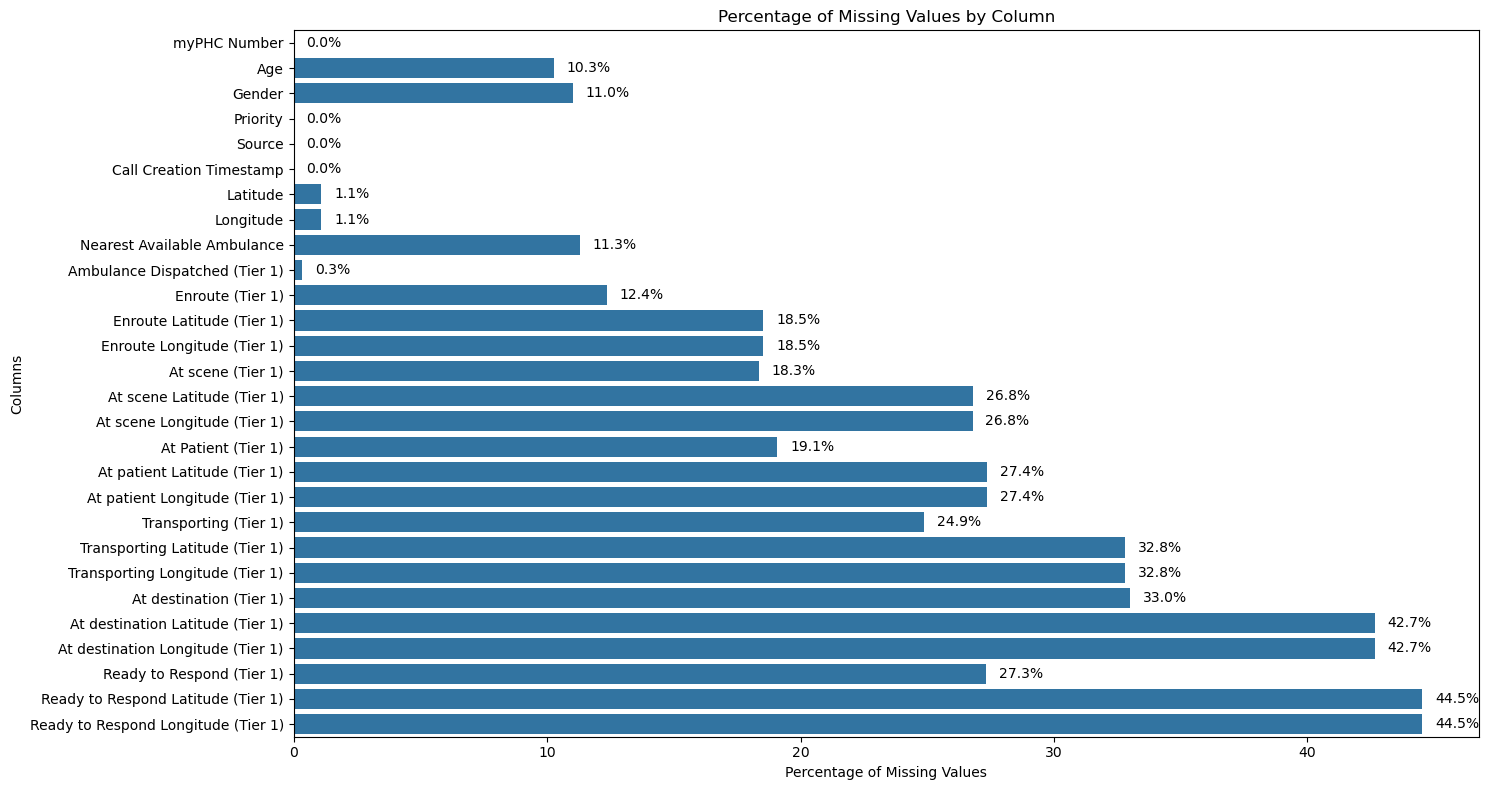

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate percentage of missing values for each column
missing_percentages = (df_selected.isna().sum() / len(df_selected)) * 100

# Create a figure with appropriate size
plt.figure(figsize=(15, 8))

# Create bar plot
sns.barplot(x=missing_percentages.values, y=missing_percentages.index)

# Customize the plot
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Columns')

# Add percentage labels on the bars
for i, v in enumerate(missing_percentages.values):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

In [6]:
# Display min and max dates for Call Creation Timestamp
print("Date Range for Call Creation Timestamp:")
print(f"Earliest date: {df_selected['Call Creation Timestamp'].min()}")
print(f"Latest date: {df_selected['Call Creation Timestamp'].max()}")

# Additional statistics
print("\nTimestamp Statistics:")
print(df_selected['Call Creation Timestamp'].describe())

Date Range for Call Creation Timestamp:
Earliest date: 2024-01-01 00:00:00
Latest date: 2024-12-31 23:45:00

Timestamp Statistics:
count                            50874
mean     2024-07-06 12:24:04.029956608
min                2024-01-01 00:00:00
25%                2024-04-07 18:11:45
50%                2024-07-09 12:57:30
75%                2024-10-04 15:43:30
max                2024-12-31 23:45:00
Name: Call Creation Timestamp, dtype: object


## 1.4 Temporal Visualization

In [7]:
# Extract day of week and hour of day
df_selected['Day_of_Week'] = df_selected['Call Creation Timestamp'].dt.day_name()
df_selected['Hour_of_Day'] = df_selected['Call Creation Timestamp'].dt.hour

# Define Malaysian public holidays for 2024
my_holidays = {
    '2024-01-01': 'New Year',
    '2024-02-10': 'Chinese New Year',
    '2024-02-11': 'Chinese New Year',
    '2024-05-01': 'Labour Day',
    '2024-05-22': 'Wesak Day',
    '2024-06-04': 'Agong Birthday',
    '2024-06-15': 'Hari Raya Haji',
    '2024-06-16': 'Hari Raya Haji',
    '2024-07-19': 'Awal Muharram',
    '2024-08-31': 'National Day',
    '2024-09-16': 'Malaysia Day',
    '2024-09-27': 'Prophet Muhammad Birthday',
    '2024-11-02': 'Deepavali',
    '2024-12-25': 'Christmas Day'
}

# Create holiday column
df_selected['Is_Holiday'] = df_selected['Call Creation Timestamp'].dt.strftime('%Y-%m-%d').map(my_holidays)
df_selected['Is_Holiday'] = df_selected['Is_Holiday'].fillna('Not Holiday')

# Display sample of the new columns
print("\nSample of timestamps with new labels:")
print(df_selected[['Call Creation Timestamp', 'Day_of_Week', 'Hour_of_Day', 'Is_Holiday']].head())

# Show distribution of calls by day of week
print("\nCalls by Day of Week:")
print(df_selected['Day_of_Week'].value_counts().sort_index())

# Show distribution of calls by hour
print("\nCalls by Hour of Day:")
print(df_selected['Hour_of_Day'].value_counts().sort_index())

# Show calls on holidays
print("\nCalls on Public Holidays:")
print(df_selected['Is_Holiday'].value_counts())


Sample of timestamps with new labels:
  Call Creation Timestamp Day_of_Week  Hour_of_Day Is_Holiday
0     2024-01-01 00:00:00      Monday            0   New Year
1     2024-01-01 00:07:00      Monday            0   New Year
2     2024-01-01 00:45:00      Monday            0   New Year
3     2024-01-01 01:29:00      Monday            1   New Year
4     2024-01-01 01:35:00      Monday            1   New Year

Calls by Day of Week:
Day_of_Week
Friday       7655
Monday       7813
Saturday     6618
Sunday       6150
Thursday     7584
Tuesday      7752
Wednesday    7302
Name: count, dtype: int64

Calls by Hour of Day:
Hour_of_Day
0     1269
1     1012
2      868
3      789
4      748
5      833
6     1385
7     2353
8     2693
9     2929
10    2875
11    2822
12    3040
13    2662
14    2640
15    2570
16    2638
17    2805
18    2975
19    2720
20    2526
21    2274
22    1892
23    1556
Name: count, dtype: int64

Calls on Public Holidays:
Is_Holiday
Not Holiday                  49099
Hari

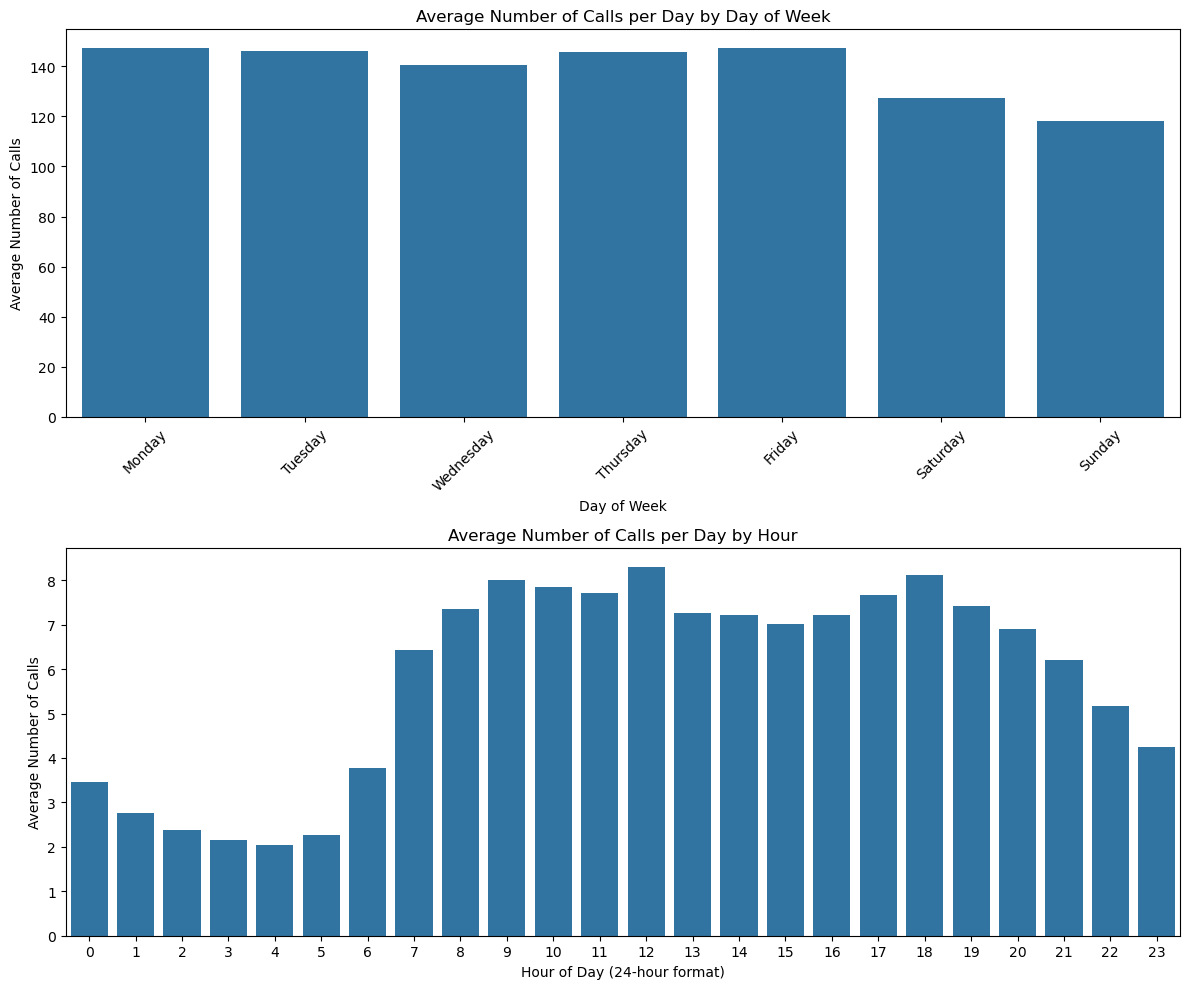


Summary Statistics:

Average Calls per Day by Day of Week:
count      7.000000
mean     138.956925
std       11.599345
min      118.269231
25%      133.846154
50%      145.846154
75%      146.737845
max      147.415094
dtype: float64

Average Calls per Day by Hour:
count    24.000000
mean      5.791667
std       2.240792
min       2.043716
25%       3.704918
50%       6.961749
75%       7.489754
max       8.306011
dtype: float64

Number of each weekday in 2024:
Monday: 53 days
Tuesday: 53 days
Wednesday: 52 days
Thursday: 52 days
Friday: 52 days
Saturday: 52 days
Sunday: 52 days


In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# Count number of each weekday in 2024 (it's a leap year)
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 12, 31)
weekday_counts = df_selected.groupby('Day_of_Week')['Call Creation Timestamp'].apply(
    lambda x: len(pd.date_range(start=start_date, end=end_date, freq='D', tz=None).day_name()[pd.date_range(start=start_date, end=end_date, freq='D', tz=None).day_name() == x.name])
)

# Calculate true daily averages
daily_avg = df_selected.groupby('Day_of_Week').size() / weekday_counts

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 1. Average calls by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = daily_avg.reindex(day_order)

sns.barplot(x=daily_avg.index, y=daily_avg.values, ax=ax1)
ax1.set_title('Average Number of Calls per Day by Day of Week')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Average Number of Calls')
ax1.tick_params(axis='x', rotation=45)

# 2. Average calls by hour
hourly_avg = df_selected.groupby('Hour_of_Day').size() / (366)  # 2024 is a leap year
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, ax=ax2)
ax2.set_title('Average Number of Calls per Day by Hour')
ax2.set_xlabel('Hour of Day (24-hour format)')
ax2.set_ylabel('Average Number of Calls')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("\nAverage Calls per Day by Day of Week:")
print(daily_avg.describe())
print("\nAverage Calls per Day by Hour:")
print(hourly_avg.describe())

# Print actual counts for reference
print("\nNumber of each weekday in 2024:")
for day in day_order:
    print(f"{day}: {weekday_counts[day]} days")

## 1.5 Geospatial Visualization 

In [56]:
# Define latitude and longitude column pairs
lat_long_columns = {
    'Call Location': ['Latitude', 'Longitude'],
    'Enroute': ['Enroute Latitude (Tier 1)', 'Enroute Longitude (Tier 1)'],
    'At Scene': ['At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)'],
    'At Patient': ['At patient Latitude (Tier 1)', 'At patient Longitude (Tier 1)'],
    'Transporting': ['Transporting Latitude (Tier 1)', 'Transporting Longitude (Tier 1)'],
    'At Destination': ['At destination Latitude (Tier 1)', 'At destination Longitude (Tier 1)'],
    'Ready to Respond': ['Ready to Respond Latitude (Tier 1)', 'Ready to Respond Longitude (Tier 1)']
}

# To access all latitude columns
lat_columns = [pair[0] for pair in lat_long_columns.values()]

# To access all longitude columns
long_columns = [pair[1] for pair in lat_long_columns.values()]

# To access both latitude and longitude columns as a flat list
all_coord_columns = [col for pair in lat_long_columns.values() for col in pair]


In [57]:
# First, check for non-numeric values in coordinate columns
def check_coordinates(df, coord_columns):
    non_numeric = {}
    for col in coord_columns:
        # Convert to string first to handle all types of values
        non_num_mask = ~df[col].astype(str).str.match(r'^-?\d*\.?\d*$')
        non_num_values = df[col][non_num_mask].unique()
        if len(non_num_values) > 0:
            non_numeric[col] = non_num_values
    return non_numeric

# Check for non-numeric values
non_numeric_coords = check_coordinates(df_selected, all_coord_columns)

# Print any non-numeric values found
if non_numeric_coords:
    print("Non-numeric values found in coordinate columns:")
    for col, values in non_numeric_coords.items():
        print(f"\n{col}:")
        print(values)

# Convert coordinates to numeric, replacing invalid values with NaN
for col in all_coord_columns:
    df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')

# Verify conversion and show summary statistics
print("\nCoordinate columns summary after conversion:")
print(df_selected[all_coord_columns].describe())

# Check for any remaining issues (inf, -inf, or unreasonable values)
print("\nChecking for invalid coordinate values:")
for col in all_coord_columns:
    invalid_count = df_selected[col].isna().sum()
    out_of_range = df_selected[
        (df_selected[col].notna()) & 
        ((df_selected[col] < -180) | (df_selected[col] > 180))
    ].shape[0]
    
    print(f"\n{col}:")
    print(f"Missing values: {invalid_count}")
    print(f"Out of range values: {out_of_range}")

Non-numeric values found in coordinate columns:

Latitude:
['undefined' <NA>]

Longitude:
['undefined' <NA>]

Enroute Latitude (Tier 1):
[<NA> '<latitude-value>']

Enroute Longitude (Tier 1):
[<NA> '<longitude-value>']

At scene Latitude (Tier 1):
[<NA>]

At scene Longitude (Tier 1):
[<NA> '9/2/2024']

At patient Latitude (Tier 1):
[<NA>]

At patient Longitude (Tier 1):
[<NA>]

Transporting Latitude (Tier 1):
[<NA>]

Transporting Longitude (Tier 1):
[<NA>]

At destination Latitude (Tier 1):
[<NA>]

At destination Longitude (Tier 1):
[<NA>]

Ready to Respond Latitude (Tier 1):
[<NA>]

Ready to Respond Longitude (Tier 1):
[<NA>]

Coordinate columns summary after conversion:
           Latitude     Longitude  Enroute Latitude (Tier 1)  \
count  49730.000000  49730.000000               37257.000000   
mean       5.316502    100.455287                   5.375932   
std        0.444107      0.866354                   0.075785   
min        0.458301     20.432023                   3.011489   

In [32]:
df_selected[all_coord_columns].tail()

,Latitude,Longitude,Enroute Latitude (Tier 1),Enroute Longitude (Tier 1),At scene Latitude (Tier 1),At scene Longitude (Tier 1),At patient Latitude (Tier 1),At patient Longitude (Tier 1),Transporting Latitude (Tier 1),Transporting Longitude (Tier 1),At destination Latitude (Tier 1),At destination Longitude (Tier 1),Ready to Respond Latitude (Tier 1),Ready to Respond Longitude (Tier 1)
50869,5.3339076,100.2815767,5.416502233,100.3101597,5.332900726,100.2890484,5.332900726,100.2890484,5.338005581,100.2923827,5.416377531,100.3100424,<NA>,<NA>
50870,5.1502069,100.4223569,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
50871,5.1502069,100.4223569,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
50872,5.418122886,100.3076004,5.4162926,100.3102554,5.3823023,100.3158222,5.382479,100.3156491,5.3804923,100.307445,5.4163633,100.3101778,5.4163137,100.3102036
50873,5.31987,100.2700067,5.416479,100.3102167,5.3137162,100.2861565,5.3137162,100.2861565,5.3801687,100.3070638,5.4166856,100.3101391,5.4164777,100.3101894


In [58]:
import plotly.express as px

fig = px.scatter_mapbox(
    lat=[5.4164],
    lon=[100.3327],
    zoom=9,
    center=dict(lat=5.4164, lon=100.3327),
    mapbox_style="open-street-map"
)
fig.show()

In [59]:
# Filter data for a single day (using the first day in the dataset)
first_day = df_selected['Call Creation Timestamp'].dt.date.min()
one_day_calls = df_selected[df_selected['Call Creation Timestamp'].dt.date == first_day]

# Create scatter mapbox plot
fig = px.scatter_mapbox(
    one_day_calls,
    lat='Latitude',
    lon='Longitude',
    hover_data=['Call Creation Timestamp', 'Priority', 'Source'],  # Show these in hover tooltip
    zoom=11,
    center=dict(lat=5.4164, lon=100.3327),
    mapbox_style="open-street-map",
    title=f'Call Locations on {first_day}'
)

# Update layout for better visibility
fig.update_layout(
    mapbox=dict(
        center=dict(lat=5.4164, lon=100.3327),
        zoom=11
    ),
    margin={"r":0,"t":30,"l":0,"b":0}
)

# Show the plot
fig.show()

# Print summary statistics
print(f"\nCall Statistics for {first_day}:")
print(f"Total calls: {len(one_day_calls)}")
print("\nCalls by Priority:")
print(one_day_calls['Priority'].value_counts())
print("\nCalls by Source:")
print(one_day_calls['Source'].value_counts())


Call Statistics for 2024-01-01:
Total calls: 134

Calls by Priority:
Priority
1    77
2    39
4    13
3     5
Name: count, dtype: int64

Calls by Source:
Source
999 call    134
Name: count, dtype: int64


In [74]:
def trace_ambulance_journey(df, phc_number):
    # Get single call record
    journey = df[df['myPHC Number'] == phc_number].iloc[0]
    
    # Create journey timeline with coordinates and all timestamps
    journey_points = []
    for stage, coords in lat_long_columns.items():
        lat, lon = coords
        point = {
            'Stage': stage,
            'Latitude': journey.get(lat, pd.NA),
            'Longitude': journey.get(lon, pd.NA)
        }
        # Add all timestamps to each point for hover data
        for ts_col in timestamp_columns:
            point[ts_col] = journey.get(ts_col, pd.NA)
        journey_points.append(point)
    
    # Convert to DataFrame and sort by respective timestamps
    journey_df = pd.DataFrame(journey_points)
    stage_to_timestamp = {
        'Call Location': 'Call Creation Timestamp',
        'Enroute': 'Enroute (Tier 1)',
        'At Scene': 'At scene (Tier 1)',
        'At Patient': 'At Patient (Tier 1)',
        'Transporting': 'Transporting (Tier 1)',
        'At Destination': 'At destination (Tier 1)',
        'Ready to Respond': 'Ready to Respond (Tier 1)'
    }
    journey_df['Sort_Timestamp'] = journey_df['Stage'].map(stage_to_timestamp).apply(lambda x: journey.get(x, pd.NaT))
    journey_df = journey_df.sort_values('Sort_Timestamp')
    
    # Plot journey on map with all timestamps in hover
    fig = px.scatter_mapbox(journey_df,
                           lat='Latitude',
                           lon='Longitude',
                           text='Stage',
                           hover_data=timestamp_columns,  # Show all timestamps in hover
                           zoom=12,
                           center=dict(lat=5.4164, lon=100.3327),
                           mapbox_style="open-street-map",
                           title=f'Ambulance Journey for PHC #{phc_number}')
    
    # Add lines connecting points
    fig.add_trace(
        px.line_mapbox(journey_df,
                       lat='Latitude',
                       lon='Longitude').data[0]
    )
    
    fig.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
    fig.show()
    
    # Print detailed journey information including all timestamps
    print(f"\nJourney Details for PHC #{phc_number}:")
    display_columns = ['Stage', 'Latitude', 'Longitude'] + timestamp_columns
    print(journey_df[display_columns].to_string(index=False))

def get_random_complete_journey(df, timestamp_cols, coordinate_cols):
    """
    Get a random complete journey from the dataset.
    
    Args:
        df (pd.DataFrame): The main dataframe containing journey data
        timestamp_cols (list): List of timestamp column names
        coordinate_cols (list): List of coordinate column names
        
    Returns:
        tuple: (phc_number, journey_data) or (None, None) if no complete journeys found
    """
    # Find rows where all timestamp columns are filled
    complete_timestamps = df[
        df[timestamp_cols].notna().all(axis=1)
    ]
    
    # Find rows where both timestamps and coordinates are filled
    complete_journeys = complete_timestamps[
        complete_timestamps[coordinate_cols].notna().all(axis=1)
    ]
    
    if len(complete_journeys) > 0:
        print(f"\nFound {len(complete_journeys)} complete journeys")
        
        # Select a random journey
        random_journey = complete_journeys.sample(n=1).iloc[0]
        sample_phc = random_journey['myPHC Number']
        
        print(f"\nSelected random journey: PHC #{sample_phc}")
        print(f"Priority: {random_journey['Priority']}")
        print(f"Call Time: {random_journey['Call Creation Timestamp']}")
        
        return sample_phc, random_journey
    else:
        print("No completely filled journeys found.")
        # Fallback to the journey with most complete data
        fallback_phc = df.loc[
            df[coordinate_cols].notna().sum(axis=1).idxmax(),
            'myPHC Number'
        ]
        return fallback_phc, df[df['myPHC Number'] == fallback_phc].iloc[0]




In [ ]:

sample_phc, journey_data = get_random_complete_journey(
    df_selected, 
    timestamp_columns, 
    all_coord_columns
)


trace_ambulance_journey(df_selected, sample_phc)



Found 20492 complete journeys

Selected random journey: PHC #myPHC-07-1120285
Priority: 2
Call Time: 2024-11-10 11:47:00



Journey Details for PHC #myPHC-07-1120285:
           Stage  Latitude  Longitude Call Creation Timestamp    Enroute (Tier 1)   At scene (Tier 1) At Patient (Tier 1) Transporting (Tier 1) At destination (Tier 1) Ready to Respond (Tier 1)
   Call Location  5.432710 100.312294     2024-11-10 11:47:00 2024-11-10 11:48:00 2024-11-10 12:00:00 2024-11-10 12:00:00   2024-11-10 12:21:00     2024-11-10 13:06:00       2024-11-10 13:31:00
         Enroute  5.333618 100.274058     2024-11-10 11:47:00 2024-11-10 11:48:00 2024-11-10 12:00:00 2024-11-10 12:00:00   2024-11-10 12:21:00     2024-11-10 13:06:00       2024-11-10 13:31:00
        At Scene  5.334125 100.275713     2024-11-10 11:47:00 2024-11-10 11:48:00 2024-11-10 12:00:00 2024-11-10 12:00:00   2024-11-10 12:21:00     2024-11-10 13:06:00       2024-11-10 13:31:00
      At Patient  5.334125 100.275713     2024-11-10 11:47:00 2024-11-10 11:48:00 2024-11-10 12:00:00 2024-11-10 12:00:00   2024-11-10 12:21:00     2024-11-10 13:06:00       2024-1

## 1.6 Export Data for Jeffery's model

In [8]:
df_selected.to_csv("Processed_EMS_Calls_Penang_2024.csv", index=False)